# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студентки гр. 2383 Анищенко Анастасия и Бараева Елизавета. Вариант №24

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Основные теоретические положения

Все множество значений, которые измеряемая величина может принимать в эксперименте, называется генеральной совокупностью. Полученный при этом ряд значений физической величины называют выборкой из генеральной совокупности или просто выборкой.

Ранжированный ряд – последовательность элементов выборки, расположенных в порядке возрастания их значений. Номер элемента ранжированного ряда в последовательности называется рангом.

Вариационный ряд – получается из ранжированного ряда в результате объединения одинаковых элементов. Элементы вариационного ряда называются вариантами.

Интервальный ряд – вариационный ряд, разделенный на интервалы.

Формула Стерджесса:
$ k = 1 + 3,31 \lg N $

Ширина интервала:
$ h = \frac{x_{max} - x_{min}}{k}$

Границы интервалов:
$ [x_{min} + (i - 1) \cdot h; x_{min} + i \cdot h) $, для $ i = 1, 2, ..., k - 1 $, где $i$ – номер интервала.

Последний интервал:
$ [x_{min} + (k - 1) \cdot h; x_{min} + k \cdot h] $

Полигон частот представляет собой ломаную, соединяющую точки, соответствующие срединным значениям интервалов группировки и частотам этих интервалов.

Эмпирической функцией распределения (функцией распределения выборки) называют функцию $ F^*(x) $, определяющую для каждого значения $x$ относительную частоту события $ X < x $.

График $ F^*(x) $ – лестничный график, длина каждой ступеньки которого равна длине соответсвующего интервала, а высота – отношению накопленной частоты до середины этого интервала к объемы выборки, т.е.
$ F^*(\tilde{x}_{i}) = \frac{m_i^{нак}}{N}; \quad m_i^{нак} = \sum^{i - 1}_{j = 1} m_j; \quad i = 1, 2, ..., k + 1 $



## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

## Задание 1

В качестве языка программирования был выбран Python, поскольку он широко используется в анализе данных и математической статистике благодаря наличию специализированных библиотек. Также его простой и понятный синтаксис делает код читаемым и удобным для реализации статистических формул и алгоритмов.

## Задание 2

Двумерная генеральная совокупность, взятая с этого [сайта](https://archive.ics.uci.edu/dataset/9/auto+mpg), была согласована с преподавателем.



## Задание 3

Из генеральной совокупности простым случайным бесповторным отбором была сформирована выборка из 110 наблюдений (признаки: объем двигателя, ускорение). Для воспроизводимости результатов использован параметр random_state=24.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_file = pd.read_csv("auto-mpg.txt", sep='\\s+', header=None, na_values='?')
sample_df = df_file.sample(n=110, random_state=24)
df = pd.DataFrame({'displacement': sample_df[0], 'acceleration': sample_df[5]}).reset_index(drop=True)
print(df)

     displacement  acceleration
0            20.0          13.5
1            31.3          17.5
2            44.0          24.6
3            18.0          14.5
4            34.0          16.9
..            ...           ...
105          14.0          13.0
106          25.0          19.0
107          28.1          20.4
108          14.0          13.5
109          15.0          21.0

[110 rows x 2 columns]


## Задание 4

In [3]:
# Ранжированный ряд столбца "объем двигателя"
ranked_displacement = df['displacement'].sort_values().reset_index(drop=True)
ranked_displacement.index = ranked_displacement.index + 1
print(ranked_displacement)

1      10.0
2      11.0
3      12.0
4      13.0
5      13.0
       ... 
106    37.3
107    38.0
108    44.0
109    44.3
110    46.6
Name: displacement, Length: 110, dtype: float64


In [4]:
# Вариационный ряд столбца "объем двигателя"
variation_displacement = df['displacement'].value_counts().sort_index().reset_index()
variation_displacement = variation_displacement.sort_values('displacement')
print(variation_displacement)

    displacement  count
0           10.0      1
1           11.0      1
2           12.0      1
3           13.0      4
4           14.0      3
5           15.0      6
6           16.0      3
7           17.0      1
8           17.5      2
9           18.0      9
10          18.6      1
11          19.0      2
12          19.4      1
13          19.9      1
14          20.0      1
15          20.2      1
16          20.5      1
17          21.0      3
18          21.5      1
19          22.0      5
20          22.3      1
21          22.4      1
22          23.0      2
23          24.0      4
24          25.0      6
25          25.5      1
26          26.0      8
27          26.6      1
28          27.0      2
29          28.0      3
30          28.1      1
31          29.0      1
32          29.5      1
33          29.8      2
34          29.9      1
35          30.0      3
36          31.0      2
37          31.3      1
38          31.5      1
39          31.8      1
40          32.0

In [5]:
N = 110
k = int(1 + 3.31 * np.log10(N))
h = (max(df['displacement']) - min(df['displacement'])) / k

# Расчет таблицы
intervals = [round(min(df['displacement']) + i * h, 1) for i in range(k + 1)]
interval_data = []

for i in range(k):
    left, right = intervals[i], intervals[i + 1]
    interval_data.append([i + 1, left, right, []])

for val in df['displacement']:
    for i, left, right, vals in interval_data:
        if (i == k and left <= val <= right) or (i < k and left <= val < right):
            vals.append(val)
            break

# Вывод таблицы
print("-" * 75)
print("|  i  |    Интервал    |   ~x_i  |   m_i  |   ~m_i   | m_нак_i | ~m_нак_i |")
print("-" * 75)

abs_acc_m_i = 0
for i, left, right, vals in interval_data:
    abs_m_i = len(vals)
    abs_acc_m_i += abs_m_i
    rel_m_i = (abs_m_i / N)
    rel_acc_m_i = (abs_acc_m_i / N)
    mid = (left + right) / 2

    if i == k:
        interval_str = f"[{left:.1f}, {right:.1f}]"
    else:
        interval_str = f"[{left:.1f}, {right:.1f})"

    print(f"| {i:2d}  |  {interval_str:10s}  |  {mid:4.2f}  |  {abs_m_i:3d}   |  {rel_m_i:4.4f}  |  {abs_acc_m_i:4d}   |  {rel_acc_m_i:4.4f}  |")

print("-" * 75)
print(f"|               Σ                |  {abs_acc_m_i:4d}  |   {rel_acc_m_i:.2f}   |         -          |")
print("-" * 75)


---------------------------------------------------------------------------
|  i  |    Интервал    |   ~x_i  |   m_i  |   ~m_i   | m_нак_i | ~m_нак_i |
---------------------------------------------------------------------------
|  1  |  [10.0, 15.2)  |  12.60  |   16   |  0.1455  |    16   |  0.1455  |
|  2  |  [15.2, 20.5)  |  17.85  |   22   |  0.2000  |    38   |  0.3455  |
|  3  |  [20.5, 25.7)  |  23.10  |   25   |  0.2273  |    63   |  0.5727  |
|  4  |  [25.7, 30.9)  |  28.30  |   23   |  0.2091  |    86   |  0.7818  |
|  5  |  [30.9, 36.1)  |  33.50  |   17   |  0.1545  |   103   |  0.9364  |
|  6  |  [36.1, 41.4)  |  38.75  |    4   |  0.0364  |   107   |  0.9727  |
|  7  |  [41.4, 46.6]  |  44.00  |    3   |  0.0273  |   110   |  1.0000  |
---------------------------------------------------------------------------
|               Σ                |   110  |   1.00   |         -          |
---------------------------------------------------------------------------


По ранжированному ряду видно, что максимальное и минимальное значения выборки равны 46,6 и 10,0 соответственно. Показатель варьируется в диапазоне 36,6 единиц.

По вариационному ряду видно, что наиболее часто встречающееся значение равно 18,0. Оно повторяется в выборке 9 раз.

По интервальному ряду видно, что максимальная частота (22,73%) наблюдается в интервале 20,5 – 25,7. Соседние интервалы (15,2–20,5 и 25,7–30,9) также имеют достаточно высокие частоты (20,0% и 20,91%). В то время как последние интервалы (36,1–41,4 и 41,4–46,6) имеют низкую концентрацию значений (3,64% и 2,73%). Следовательно, можно сделать вывод, что основная масса наблюдений сосредоточена в центральной части распределения с некоторым смещением к начальным значениям признака.

## Задание 5

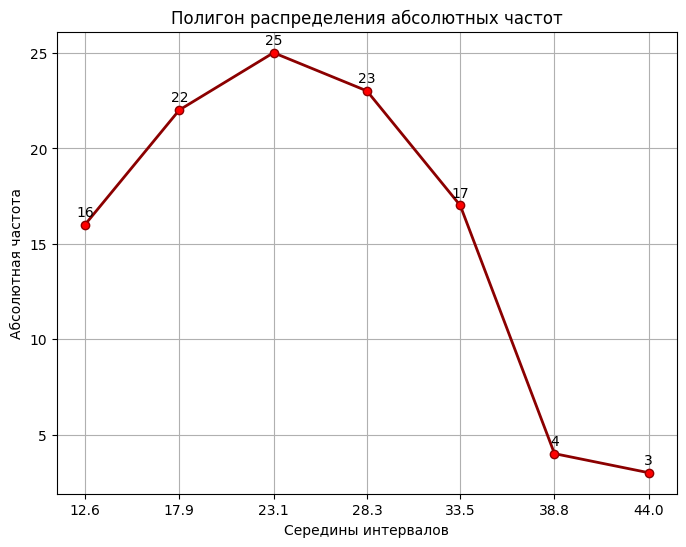

In [6]:
# Подготовка данных
intervals_mid = []  # середины интервалов
frequencies = []    # абсолютные частоты

for i, left, right, vals in interval_data:
    mid = (left + right) / 2
    freq = len(vals)

    intervals_mid.append(mid)
    frequencies.append(freq)

# Построение полигона частот
plt.figure(figsize=(8, 6))
plt.plot(intervals_mid, frequencies, 'o-', color='darkred', linewidth=2, markersize=6, markerfacecolor='red')
plt.xticks(intervals_mid, [f'{x:.1f}' for x in intervals_mid])
for x, y in zip(intervals_mid, frequencies):
    plt.text(x, y + 0.3, str(y), ha='center', va='bottom')

plt.title('Полигон распределения абсолютных частот')
plt.xlabel('Середины интервалов')
plt.ylabel('Абсолютная частота')
plt.grid()
plt.show()

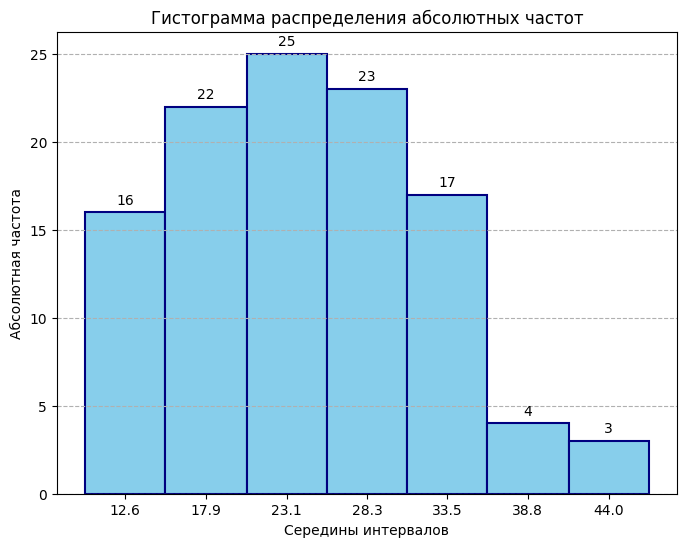

In [7]:
# Подготовка данных
left_bounds = []    # левые границы интервалов
right_bounds = []   # правые границы интервалов

for i, left, right, vals in interval_data:
    left_bounds.append(left)
    right_bounds.append(right)

# Построение гистограммы
plt.figure(figsize=(8, 6))

for i in range(k):
    left = left_bounds[i]
    right = right_bounds[i]
    height = frequencies[i]
    plt.bar(left, height, width = right - left, align='edge', color='skyblue', edgecolor='navy', linewidth=1.5)

for i in range(len(intervals_mid)):
    left = left_bounds[i]
    right = right_bounds[i]
    height = frequencies[i]
    plt.text(left + (right - left) / 2, height + 0.3, str(height), ha='center', va='bottom')

plt.xticks(intervals_mid, [f'{x:.1f}' for x in intervals_mid])

plt.title('Гистограмма распределения абсолютных частот')
plt.xlabel('Середины интервалов')
plt.ylabel('Абсолютная частота')
plt.grid(True, linestyle='--', axis='y')
plt.show()

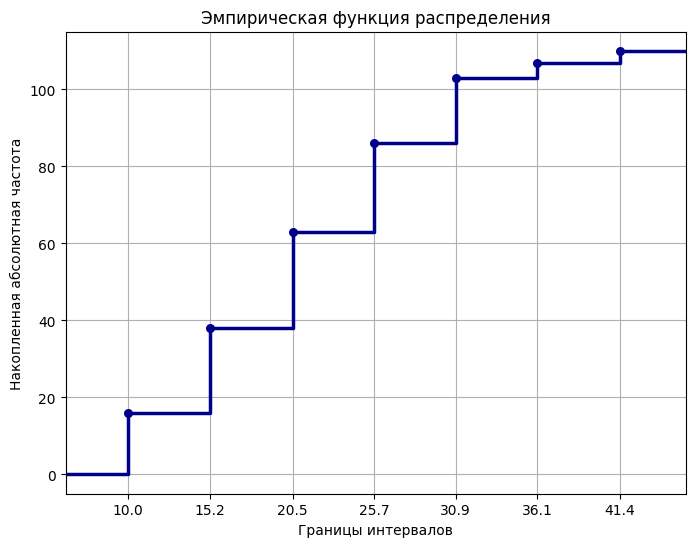

In [8]:
# Подготовка данных
accumulated_freq = [] # накопленные частоты

acc_sum = 0
for i, left, right, vals in interval_data:
    acc_sum += len(vals)
    accumulated_freq.append(acc_sum)

x_step = [0] + intervals
y_step = [0] + accumulated_freq + [1.0]

# Построение эмпирической функции распределения
plt.figure(figsize=(8, 6))
plt.step(x_step, y_step, where='post', linewidth=2.5, color='darkblue')
plt.scatter(x_step[:-1], y_step[:-1], color='darkblue', s=30, zorder=5)
plt.xticks(x_step, [f'{x:.1f}' for x in x_step])

plt.title('Эмпирическая функция распределения')
plt.ylabel('Накопленная абсолютная частота')
plt.xlabel('Границы интервалов')
plt.ylim(-5, 115)
plt.xlim(intervals[0] - 4, intervals[-1] - 1)
plt.grid()
plt.show()

Форма распределения исследуемого признака и его основные особенности наглядно представлены на гистограмме и графике полигона абсолютных частот. Наибольшая частота наблюдается в середине интервала со значением 23,1, где сосредоточено 25 наблюдений, по мере удаления от которого частоты постепенно уменьшаются, особенно резко в правой части распределения после 33,5, где наблюдается всего 4 и 3 значения. Следовательно, распределение является одновершинным и имеет правостороннюю асимметрию.

Эмпирическая функция распределения показывает накопление наблюдений по мере возрастания признака и имеет ступенчатый неубывающий характер. Наиболее резкие скачки функции соответствуют интервалам с наибольшими частотами, что также подтверждает концентрацию данных в диапазоне примерно от 15,2 до 25,7. Пологая форма функции распределения в правой части графика, начиная с 36,1, подтверждает, что значения выше этого уровня встречаются в выборке крайне редко. Характер эмпирической функции подтверждает вывод о правосторонней асимметрии.


## Задание 6

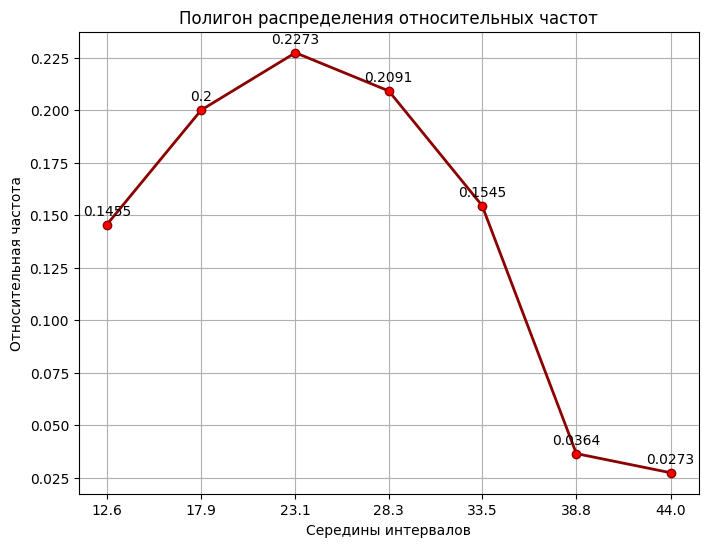

In [9]:
# Подготовка данных
intervals_mid = []  # середины интервалов
frequencies = []    # относительные частоты

for i, left, right, vals in interval_data:
    mid = (left + right) / 2
    freq = round(len(vals) / N, 4)

    intervals_mid.append(mid)
    frequencies.append(freq)

# Построение полигона частот
plt.figure(figsize=(8, 6))
plt.plot(intervals_mid, frequencies, 'o-', color='darkred', linewidth=2, markersize=6, markerfacecolor='red')
plt.xticks(intervals_mid, [f'{x:.1f}' for x in intervals_mid])
for x, y in zip(intervals_mid, frequencies):
    plt.text(x, y + 0.003, str(y), ha='center', va='bottom')

plt.title('Полигон распределения относительных частот')
plt.xlabel('Середины интервалов')
plt.ylabel('Относительная частота')
plt.grid()
plt.show()

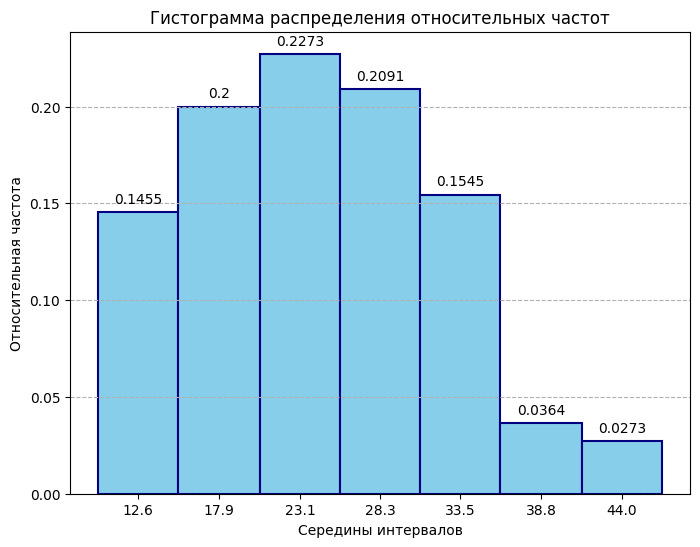

In [10]:
# Подготовка данных
left_bounds = []    # левые границы интервалов
right_bounds = []   # правые границы интервалов

for i, left, right, vals in interval_data:
    left_bounds.append(left)
    right_bounds.append(right)

# Построение гистограммы
plt.figure(figsize=(8, 6))

for i in range(k):
    left = left_bounds[i]
    right = right_bounds[i]
    height = frequencies[i]
    plt.bar(left, height, width = right - left, align='edge', color='skyblue', edgecolor='navy', linewidth=1.5)

for i in range(len(intervals_mid)):
    left = left_bounds[i]
    right = right_bounds[i]
    height = frequencies[i]
    plt.text(left + (right - left) / 2, height + 0.003, str(height), ha='center', va='bottom')

plt.xticks(intervals_mid, [f'{x:.1f}' for x in intervals_mid])

plt.title('Гистограмма распределения относительных частот')
plt.xlabel('Середины интервалов')
plt.ylabel('Относительная частота')
plt.grid(True, linestyle='--', axis='y')
plt.show()

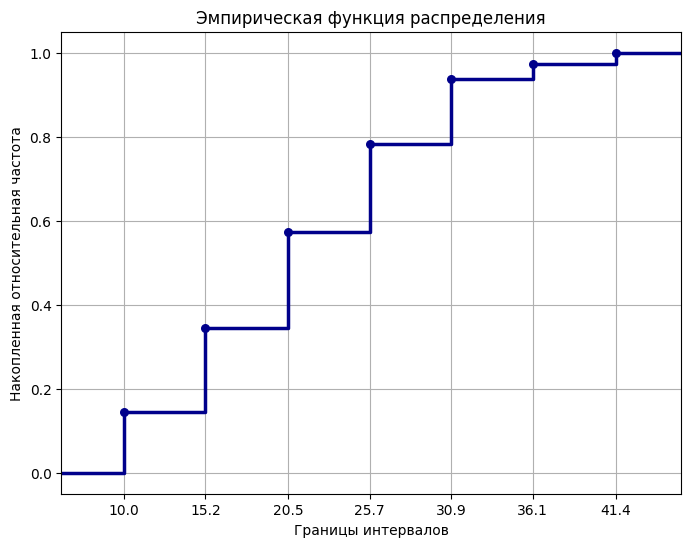

In [11]:
# Подготовка данных
accumulated_freq = [] # накопленные частоты

acc_sum = 0
for i, left, right, vals in interval_data:
    acc_sum += len(vals)
    accumulated_freq.append(acc_sum)

x_step = [0] + intervals
y_step = [0] + [i / N for i in accumulated_freq] + [1.0]

# Построение эмпирической функции распределения
plt.figure(figsize=(8, 6))
plt.step(x_step, y_step, where='post', linewidth=2.5, color='darkblue')
plt.scatter(x_step[:-1], y_step[:-1], color='darkblue', s=30, zorder=5)
plt.xticks(x_step, [f'{x:.1f}' for x in x_step])

plt.title('Эмпирическая функция распределения')
plt.ylabel('Накопленная относительная частота')
plt.xlabel('Границы интервалов')
plt.ylim(-0.05, 1.05)
plt.xlim(intervals[0] - 4, intervals[-1] - 1)
plt.grid()
plt.show()

Графики абсолютных и относительных частот идентичны по форме, различие лишь в масштабе оси ординат. Нормировка относительных частот на объем выборки делает площадь гистограммы равной единице, что позволяет интерпретировать ее как оценку плотности распределения и корректно сравнивать выборки разного объема. При этом характер распределения полностью сохраняется. Кривая накопленных относительных частот монотонно растёт от 0 до 1, соответствуя свойствам интегральной функции распределения. Следовательно, абсолютные частоты дают представление о численности наблюдений, а относительные служат для вероятностной интерпретации и сравнения распределений.



## Выводы

В ходе выполнения лабораторной работы была проведена статистическая обработка одномерной выборки объемом 110 наблюдений. Были сформированы ранжированный, вариационный и интервальный ряды распределения, рассчитаны абсолютные, относительные и накопленные частоты. С использованием формулы Стерджесса определено оптимальное число интервалов и выполнена группировка исходных данных. По полученным результатам были построены гистограммы, полигоны абсолютных и относительных частот, эмпирическая функция распределения.

Был проведен анализ формы распределения и характера концентрации значений. Выполнено сопоставление графиков абсолютных и относительных частот, которое показало их геометрическую идентичность при различии масштаба оси ординат. Корректность расчетов была подтверждена тем, что сумма относительных частот равна единице, а последняя накопленная частота совпадает с объемом выборки. Разделение данных на интервалы позволило проследить закономерности изменения частот, определить преобладающий диапазон значений и оценить структуру распределения в целом.
